In [1]:
import sys
print(sys.executable)


/home/rohith/Documents/UH_DataScience/ds-chatbot/.venv/bin/python


In [2]:
import pandas as pd

train = pd.read_csv("../data/raw/train.csv")
test  = pd.read_csv("../data/raw/test.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Columns:", train.columns.tolist())

train.head()


Train shape: (10003, 2)
Test shape : (3080, 2)
Columns: ['text', 'category']


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [3]:
train.isna().sum()


text        0
category    0
dtype: int64

/tmp/ipykernel_36592/4012969929.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


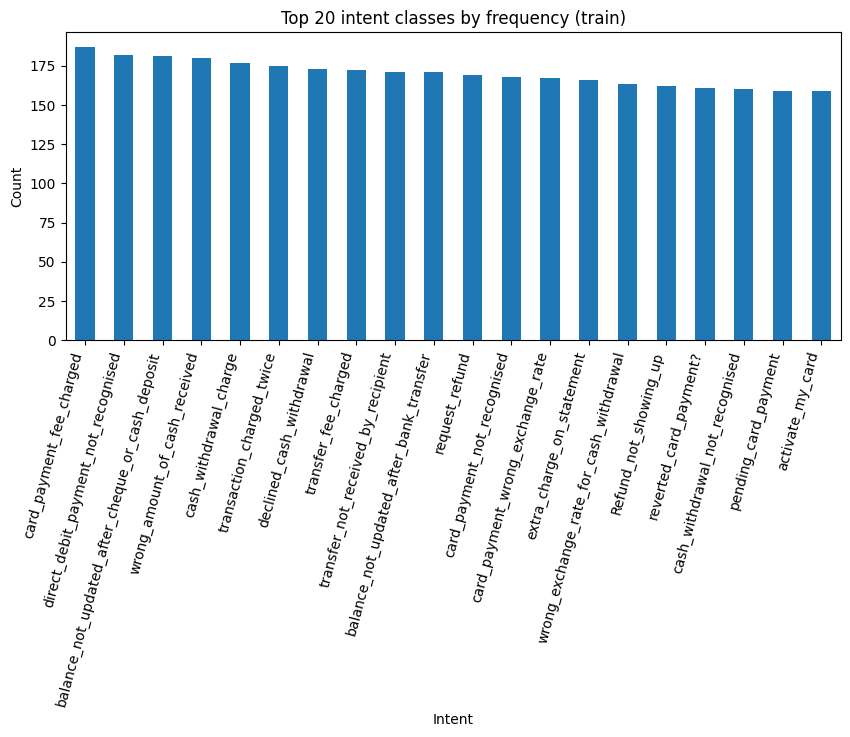

Min samples per intent: 35
Max samples per intent: 187
Mean samples per intent: 129.91


In [4]:
import matplotlib.pyplot as plt

intent_counts = train["category"].value_counts()

plt.figure(figsize=(10,4))
intent_counts.head(20).plot(kind="bar")
plt.title("Top 20 intent classes by frequency (train)")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

print("Min samples per intent:", intent_counts.min())
print("Max samples per intent:", intent_counts.max())
print("Mean samples per intent:", round(intent_counts.mean(), 2))


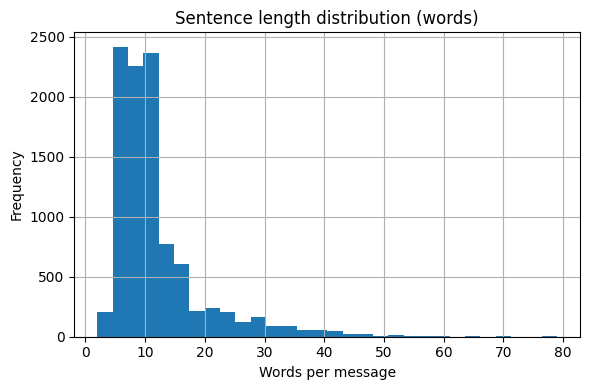

count    10003.000000
mean        11.949415
std          7.891577
min          2.000000
25%          7.000000
50%         10.000000
75%         13.000000
max         79.000000
Name: text_len, dtype: float64

In [5]:
train["text_len"] = train["text"].astype(str).str.split().str.len()

plt.figure(figsize=(6,4))
train["text_len"].hist(bins=30)
plt.title("Sentence length distribution (words)")
plt.xlabel("Words per message")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

train["text_len"].describe()


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [7]:
X = train["text"]
y = train["category"]

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

In [10]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

X_train_tfidf.shape

(8002, 8903)

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=3000,
    n_jobs=-1
)

model.fit(X_train_tfidf, y_train)

/home/rohith/Documents/UH_DataScience/ds-chatbot/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [12]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_val_tfidf)

print("Validation Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Validation Accuracy: 0.8440779610194903
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.97      0.91      0.94        32
                                activate_my_card       0.97      0.94      0.95        32
                                       age_limit       1.00      0.91      0.95        22
                         apple_pay_or_google_pay       0.96      0.96      0.96        25
                                     atm_support       0.74      0.82      0.78        17
                                automatic_top_up       1.00      0.84      0.91        25
         balance_not_updated_after_bank_transfer       0.76      0.76      0.76        34
balance_not_updated_after_cheque_or_cash_deposit       0.84      0.86      0.85        36
                         beneficiary_not_allowed       0.81      0.81      0.81        31
                                 cancel_transfer       0.85

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

<Figure size 1000x1000 with 0 Axes>

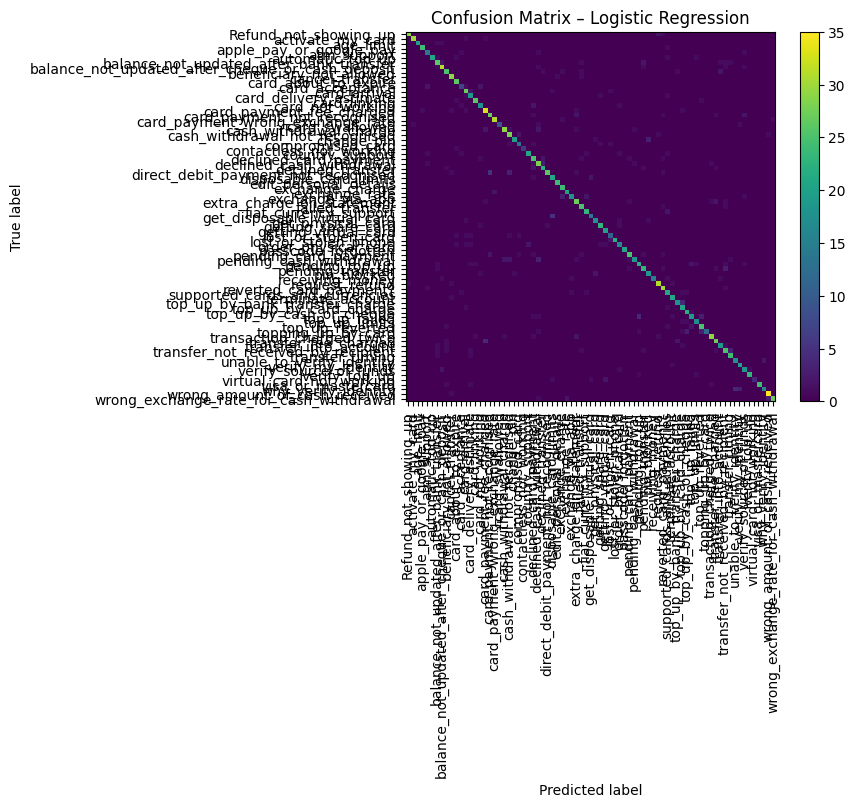

In [14]:
plt.figure(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred,
    xticks_rotation=90,
    include_values=False
)
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

svm model


In [16]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_val_tfidf)

print("SVM Validation Accuracy:", accuracy_score(y_val, svm_pred))
print(classification_report(y_val, svm_pred))

SVM Validation Accuracy: 0.88055972013993
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.91      0.94      0.92        32
                                activate_my_card       0.97      0.94      0.95        32
                                       age_limit       0.95      0.95      0.95        22
                         apple_pay_or_google_pay       1.00      0.96      0.98        25
                                     atm_support       0.88      0.88      0.88        17
                                automatic_top_up       1.00      0.92      0.96        25
         balance_not_updated_after_bank_transfer       0.81      0.76      0.79        34
balance_not_updated_after_cheque_or_cash_deposit       0.89      0.92      0.90        36
                         beneficiary_not_allowed       0.84      0.87      0.86        31
                                 cancel_transfer       1.